# 01 - Data Generation

This project uses a **synthetic** EV charging session dataset, since a real public dataset with 50k-100k per-session records (timestamps, energy, revenue, station-level detail) is not freely available without usage restrictions. The generator (`python/data_generation.py`) builds realistic statistical relationships: peak-hour demand curves, weekday/weekend and monthly seasonality, station-level demand tiers, and utilization-driven waiting times. All records are explicitly flagged `is_synthetic = True`.

In [1]:
import sys
sys.path.insert(0, '../python')
import pandas as pd
import data_generation as dg

stations_df = dg.build_station_master()
print(f'Stations created: {len(stations_df)} across {stations_df.city.nunique()} cities')
stations_df.head()

Stations created: 73 across 5 cities


,station_id,station_name,city,area,latitude,longitude,charger_type,number_of_chargers,demand_tier
0,ST1001,Connaught Place EV Hub 1001,Delhi,Connaught Place,28.67033,77.09194,AC Fast (7.4kW),6,low
1,ST1002,Connaught Place EV Hub 1002,Delhi,Connaught Place,28.61289,77.15782,DC Ultra-Fast (150kW),3,moderate
2,ST1003,Dwarka EV Hub 1003,Delhi,Dwarka,28.68153,77.23705,AC Fast (7.4kW),3,moderate
3,ST1004,Dwarka EV Hub 1004,Delhi,Dwarka,28.55637,77.26171,AC Fast (7.4kW),7,moderate
4,ST1005,Dwarka EV Hub 1005,Delhi,Dwarka,28.68725,77.19973,DC Fast (50kW),2,high


## Generate sessions and inspect the raw (intentionally dirty) output

In [2]:
sessions_df = dg.generate_sessions(stations_df, n_sessions=20000)  # smaller sample for notebook speed
dirty_df = dg.dirty_the_data(sessions_df)
print(f'Rows after introducing data-quality issues: {len(dirty_df)}')
dirty_df.isna().sum().sort_values(ascending=False).head(8)

Rows after introducing data-quality issues: 20200


weather_condition       604
waiting_time_minutes    400
energy_consumed_kwh     204
charging_cost           202
vehicle_type            101
date                      0
start_time                0
end_time                  0
dtype: int64

## Sanity-check the built-in relationships
Peak hours (8-9, 18-20) should show higher session counts than off-peak hours.

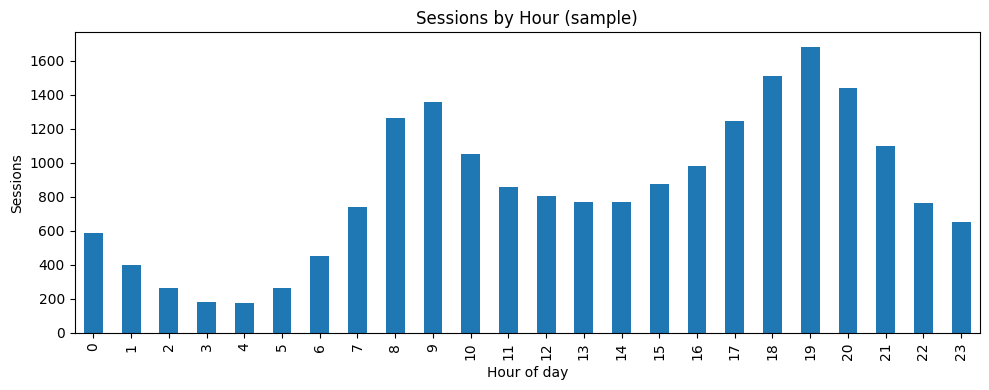

In [3]:
dirty_df['hour'].value_counts().sort_index().plot(kind='bar', figsize=(10,4), title='Sessions by Hour (sample)')
import matplotlib.pyplot as plt
plt.xlabel('Hour of day'); plt.ylabel('Sessions'); plt.tight_layout(); plt.show()

The full 85,000-row dataset used for the rest of the project is produced by running:

```bash
python python/data_generation.py
```

which writes `data/raw/ev_charging_raw.csv` and `data/raw/station_master.csv`.